<a href="https://colab.research.google.com/github/hyui02/miniproject1/blob/main/%EC%98%81%ED%99%94%EA%B4%80%EA%B0%9D_%EA%B0%90%EB%8F%85_%ED%8F%AC%EC%BB%A4%EC%8B%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

train = pd.read_csv('/content/movies_train.csv')

In [ ]:
#한글 폰트 깨짐 방지
!apt-get -qq -y install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

#0단계 변수 구조
결측이 어느 행에서 생기는지 확인

In [ ]:
train.isna().sum()

,0
title,0
distributor,0
genre,0
release_time,0
time,0
screening_rat,0
director,0
dir_prev_bfnum,330
dir_prev_num,0
num_staff,0


In [ ]:
train['dir_prev_bfnum'] = train['dir_prev_bfnum'].fillna(0)

In [ ]:
train['is_newbie'] = train['dir_prev_num'] == 0
train['director_type'] = np.where(train['is_newbie'], '신인', '경력')
print(train['director_type'].value_counts())

director_type
신인    330
경력    270
Name: count, dtype: int64


##결과

(1) dir_prev_bfnum(전작 평균 관객수)의 결측 330개는 dir_prev_num(전작 편수)이 0인 행 330개와 정확히 일치했다. 전작이 없는 신인 감독은 평균 관객수를 계산할 수 없어 결측이 생긴 것이.따라서 이를 평균으로 채우지 않고 0으로 채웠다.

(2) dir_prev_num을 기준으로 전작이 없는 감독을 신인(330편), 있는 감독을 경력(270편)으로 구분했다.

#1단계. 단순 비교

In [ ]:
raw = train.groupby('director_type')[['box_off_num', 'num_staff']].median().loc[['신인', '경력']]
print(raw)
print(raw.loc['경력'] / raw.loc['신인'])

               box_off_num  num_staff
director_type                        
신인                  3401.5       37.5
경력                222258.0      215.5
box_off_num    65.341173
num_staff       5.746667
dtype: float64


/tmp/ipykernel_48206/1437793560.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=raw.index, y=raw['box_off_num'], palette='deep', ax=ax[0])
/tmp/ipykernel_48206/1437793560.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=raw.index, y=raw['num_staff'], palette='deep', ax=ax[1])


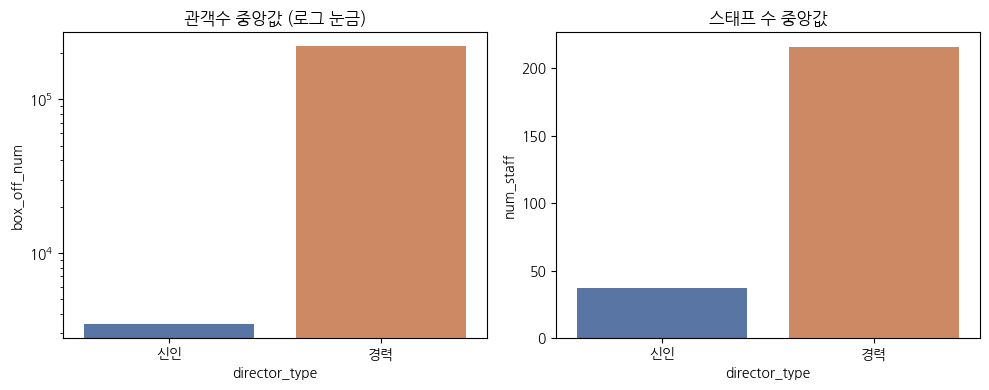

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(x=raw.index, y=raw['box_off_num'], palette='deep', ax=ax[0])
ax[0].set_yscale('log')
ax[0].set_title('관객수 중앙값 (로그 눈금)')
sns.barplot(x=raw.index, y=raw['num_staff'], palette='deep', ax=ax[1])
ax[1].set_title('스태프 수 중앙값')
plt.tight_layout()
plt.show()

#2단계 제작 규모 고정
이제 규모를 같은 수준으로 맞춰놓고 비교



In [ ]:
#규모 고정
train['scale'] = pd.cut(train['num_staff'], [-1, 80, 250, 900], labels=['소(~80)', '중(81~250)', '대(251+)'])

scale          소(~80)  중(81~250)  대(251+)
director_type                            
신인               66.4       21.5     12.1
경력               28.9       24.8     46.3


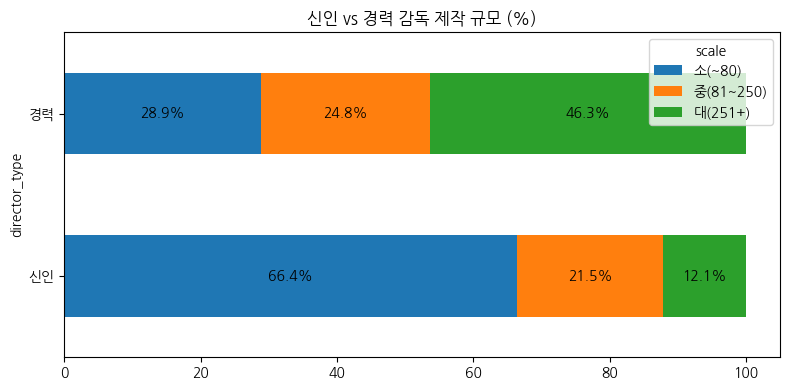

In [ ]:
comp = pd.crosstab(train['director_type'], train['scale'], normalize='index').loc[['신인', '경력']] * 100
print(comp.round(1))

ax = comp.plot(kind='barh', stacked=True, figsize=(8, 4))
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center')
plt.title('신인 vs 경력 감독 제작 규모 (%)')
plt.tight_layout()
plt.show()

scale          소(~80)  중(81~250)    대(251+)
director_type                              
경력             1878.0    35567.0  1310895.0
신인             1806.0     9323.0   885336.0
scale
소(~80)       1.039867
중(81~250)    3.814974
대(251+)      1.480674
dtype: float64


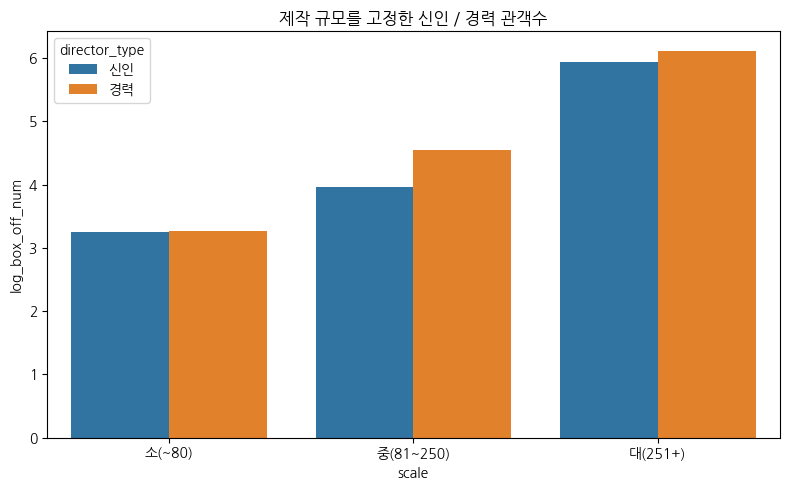

In [ ]:
train['log_box_off_num'] = np.log10(train['box_off_num'])

med = train.pivot_table(index='director_type', columns='scale', values='box_off_num',
                        aggfunc='median', observed=True)
print(med.round(0))
print(med.loc['경력'] / med.loc['신인'])

plt.figure(figsize=(8, 5))
sns.barplot(x='scale', y='log_box_off_num', hue='director_type', data=train,
            estimator=np.median, errorbar=None, hue_order=['신인', '경력'])
plt.title('제작 규모를 고정한 신인 / 경력 관객수')
plt.tight_layout()
plt.show()

#3단계 경력을 기준으로 전작의 흥행도가 다음 작품 흥행으로 이어지나

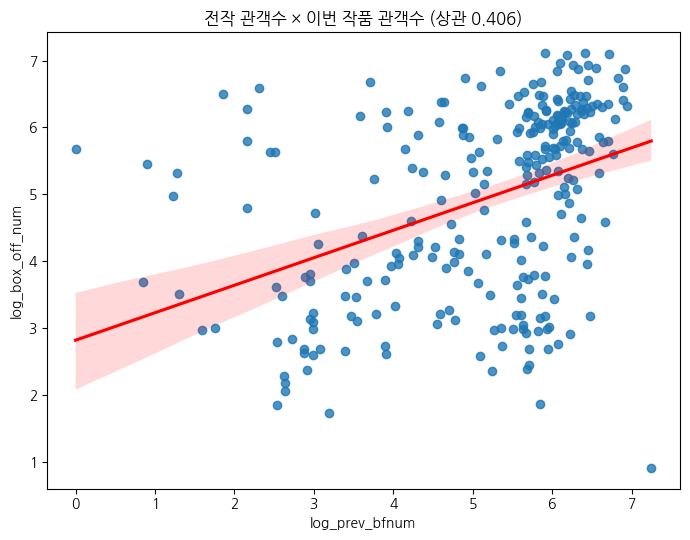

In [ ]:
#분포가 한쪽으로 크게 치어쳐 있어서 로그변환
train['log_box_off_num'] = np.log10(train['box_off_num'])
train_prev = train[train['dir_prev_num'] > 0].copy()
train_prev['log_prev_bfnum'] = np.log10(train_prev['dir_prev_bfnum'])
corr = train_prev['log_prev_bfnum'].corr(train_prev['log_box_off_num'])


plt.figure(figsize=(7, 5.5))
sns.regplot(x='log_prev_bfnum', y='log_box_off_num', data=train_prev,
            line_kws={'color': 'red'})
plt.title(f'전작 관객수 × 이번 작품 관객수 (상관 {corr:.3f})')
plt.tight_layout()
plt.show()

전작이 있는 경력 감독 270명만 놓고 전작 평균 관객수와 이번 작품 관객수의 관계를 보면, 상관계수는 0.406으로 전작이 좋을수록 이번에도 어느 정도 높은 경향이 있으나 점이 넓게 흩어져 있어 예측력은 약하다. 그렇다면 전작이 잘된 감독은 다음에도 더 잘될까? 이를 확인하기 위해 전작 성적을 4구간으로 나눠 이번 작품이 전작보다 흥행했는지를 비교했다.

         n_films  prev_median  now_median  grew_pct
prev_q                                             
하위 25%        69       1047.0      5693.0      63.8
중하위 25%       66     142322.8     28442.0      37.9
중상위 25%       67     813164.0    526547.0      40.3
상위 25%        68    2270048.5   1519376.0      30.9


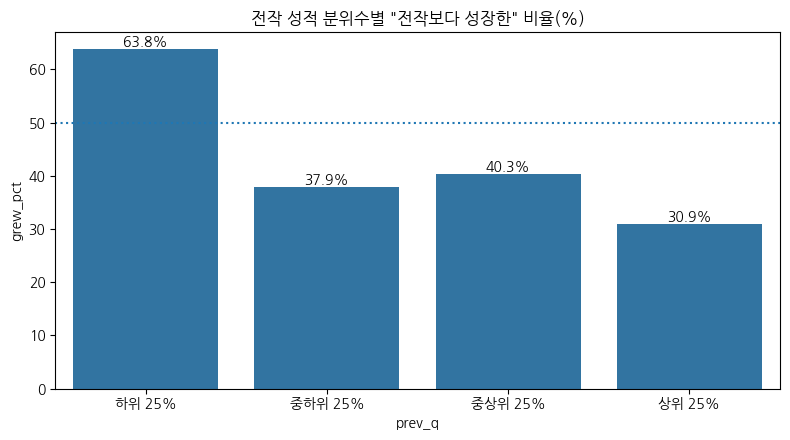

In [ ]:
train_prev['prev_q'] = pd.qcut(train_prev['dir_prev_bfnum'], 4,
                               labels=['하위 25%', '중하위 25%', '중상위 25%', '상위 25%'])
train_prev['grew'] = train_prev['box_off_num'] > train_prev['dir_prev_bfnum']

summary = train_prev.groupby('prev_q', observed=True).agg(
    n_films=('grew', 'size'),
    prev_median=('dir_prev_bfnum', 'median'),
    now_median=('box_off_num', 'median'),
    grew_pct=('grew', lambda s: s.mean() * 100))
print(summary.round(1))

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(x=summary.index, y=summary['grew_pct'])
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.axhline(50, linestyle=':')
plt.title('전작 성적 분위수별 "전작보다 성장한" 비율(%)')
plt.tight_layout()
plt.show()

전작 성적 하위 25%는 63.8%가 전작보다 성장한 반면, 상위 25%는 30.9%만 성장했다. 전작이 잘된 감독일수록 이번에도 관객수 자체는 높지만(중앙값 152만 vs 5,693명) 전작보다는 떨어지는 경우가 많다. 전작의 대박에는 실력뿐 아니라 운도 섞여 있고, 운은 다음 작품에 이어지지 않는 평균회귀 현상으로 해석할 수 있다.

#4단계 이 변수를 믿어도 되나 (한계)
앞선 1~3단계의 결론은 모두 dir_prev_num(전작 편수)이 감독의 실제 경력을 정확히 반영한다는 전제 위에 있다. 이번 단계에선 그 전제 자체를 확인하고자 한다.
- 확인 방법: 한 감독이 영화를 여러 편 만들면 dir_prev_num(그 영화 이전에 만든 편수)은 0, 1, 2처럼 커져야 한다. 이를 확인하기 위해 3편 이상 등장하는 감독의 값이 편마다 바뀌는지 살펴봤다.

3편 이상 등장하는 감독 수: 20
status
고정(의심)    12
변함         8
Name: count, dtype: int64


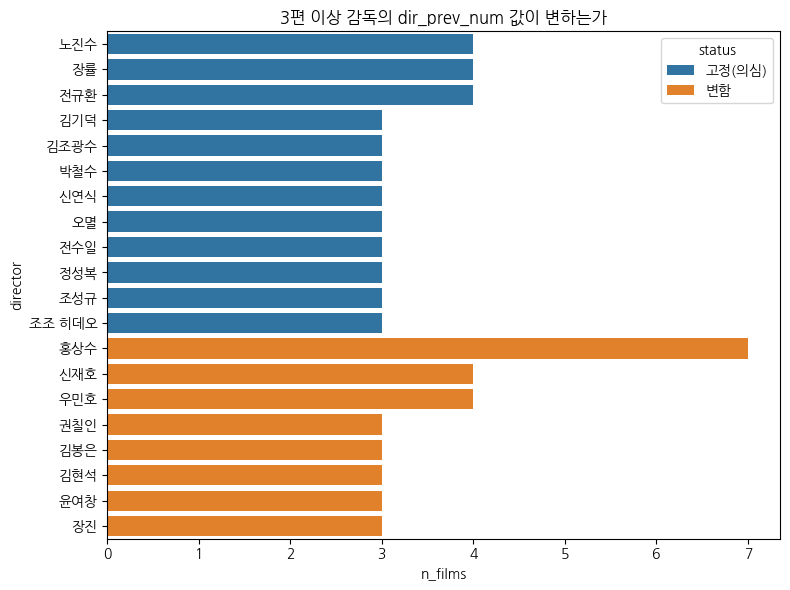

In [ ]:
counts = train['director'].value_counts()
multi = counts[counts >= 3].index
varies = train[train['director'].isin(multi)].groupby('director')['dir_prev_num'].nunique() > 1

summary = (pd.DataFrame({'n_films': counts[multi], 'varies': varies})
           .sort_values(['varies', 'n_films'], ascending=[True, False]).reset_index())
summary['status'] = np.where(summary['varies'], '변함', '고정(의심)')
print('3편 이상 등장하는 감독 수:', len(summary))
print(summary['status'].value_counts())

plt.figure(figsize=(8, 6))
sns.barplot(x='n_films', y='director', hue='status', data=summary, dodge=False)
plt.title('3편 이상 감독의 dir_prev_num 값이 변하는가')
plt.tight_layout()
plt.show()

           title release_time  dir_prev_num  box_off_num
19           하하하   2010-05-05             0        57029
523       옥희의 영화   2010-09-16             0        37122
115         북촌방향   2011-09-08             0        46212
331       다른나라에서   2012-05-31             0        31101
506        우리 선희   2013-09-12             0        69122
15        자유의 언덕   2014-09-04             0        39317
164  지금은맞고그때는틀리다   2015-09-24             1        80734


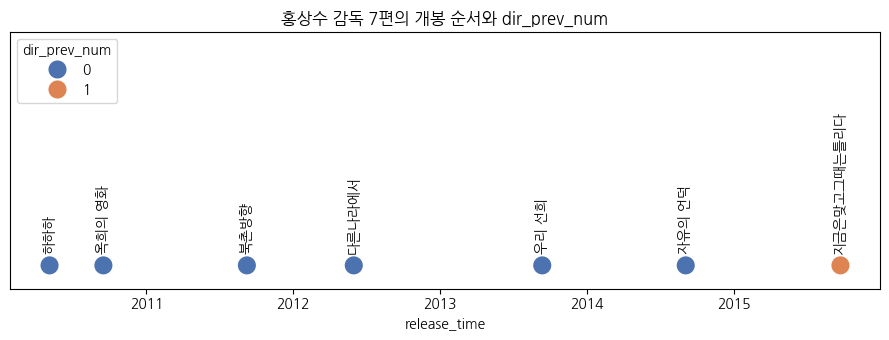

In [ ]:
#편수가 가장 많은 홍상수 감독을 기준으로 신뢰할 만한 변수임을 검증해보자

train['release_time'] = pd.to_datetime(train['release_time'])
hong = train[train['director'] == '홍상수'].sort_values('release_time')
print(hong[['title', 'release_time', 'dir_prev_num', 'box_off_num']])

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.scatterplot(x='release_time', y=0, hue='dir_prev_num', data=hong, s=200, palette='deep', ax=ax)
for _, r in hong.iterrows():
    ax.text(r['release_time'], 0.01, r['title'], rotation=90, ha='center', va='bottom')
ax.set_ylim(-0.02, 0.2)
ax.set_yticks([])
ax.legend(loc='upper left', title='dir_prev_num')
ax.set_title('홍상수 감독 7편의 개봉 순서와 dir_prev_num')
plt.tight_layout()
plt.show()